# Evaluación de clasificadores . Derecho a las Víctimas

## ¿Qué hace este notebook?

Compara las predicciones de cualquier clasificador contra las etiquetas reales del test set y muestra:

- Métricas principales (Accuracy, F1, Precision, Recall, Kappa)
- Matriz de confusión
- Análisis de errores 

**Para evaluar un clasificador nuevo:** se cambian las rutas en la Sección 1 y se corren todas las celdas 


### Nota sobre las métricas

La métrica principal es **F1 macro**, no Accuracy, porque las clases están desbalanceadas (más negativos que positivos). Además para Kappa el criterio es el siguiente:

| Kappa     | Interpretación   |
| < 0.0     | Peor que el azar |
| 0.0 – 0.2 | Leve             |
| 0.2 – 0.4 | Débil            |
| 0.4 – 0.6 | Moderado         |
| 0.6 – 0.8 | Bueno            | 
| > 0.8     | Excelente        |

> **Observación:** los falsos negativos (predijo NO, era SÍ) son más costosos que los falsos positivos en este dominio, porque perder una norma de derechos de víctimas es peor que incluir una de más.

## 1. Configuración

**Solo modificar esta sección para evaluar un clasificador nuevo.**

In [ ]:
#  Archivo con las predicciones del clasificador a evaluar 
# Debe tener columnas: 'Número' y 'caso_ok' (la predicción)
# Opcionalmente: 'Justificación' para el análisis de errores
FILE_PREDICCIONES  = 'resultado_ollama_3.2.xlsx'

# Nombre del clasificador (aparece en los gráficos y tablas)
NOMBRE_CLASIFICADOR = 'Ollama'

# Archivo original con las etiquetas reales
FILE_ORIGINAL = 'Normativa_nacional_víctimas_1869-2023.xlsx'

#Archivo test con las etiquetas originales 
FILE_TEST_ETIQUETAS =  'test_con_etiqueta.xlsx'

# Parámetros del split
TEST_SIZE    = 0.30
RANDOM_STATE = 42

## 2. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, cohen_kappa_score
)
from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})


## 3. Carga y merge de datos

In [3]:
df_pred = pd.read_excel(FILE_PREDICCIONES)
df_test = pd.read_excel(FILE_TEST_ETIQUETAS)
df_pred['Número'] = df_pred['Número'].astype(str).str.strip()
df_test['Número'] = df_test['Número'].astype(str).str.strip()

merged = df_pred.merge(
    df_test[['Número', 'caso_ok']],
    on='Número',
    suffixes=('_pred', '_real')
)
merged = merged[merged['caso_ok_pred'] != -1]
n = len(merged)

y_pred = merged['caso_ok_pred']
y_real = merged['caso_ok_real']

## 4. Métricas

In [4]:
# Tabla de métricas
metricas = {
    'Accuracy':              round(accuracy_score(y_real, y_pred), 3),
    'F1 macro':            round(f1_score(y_real, y_pred, average='macro'), 3),
    'F1 positivos (SÍ)':     round(f1_score(y_real, y_pred, pos_label=1), 3),
    'F1 negativos (NO)':     round(f1_score(y_real, y_pred, pos_label=0), 3),
    'Precision positivos':   round(precision_score(y_real, y_pred, pos_label=1), 3),
    'Recall positivos':      round(recall_score(y_real, y_pred, pos_label=1), 3),
    'Kappa':                 round(cohen_kappa_score(y_real, y_pred), 3),
}

df_metricas = pd.DataFrame(
    metricas.items(), columns=['Métrica', 'Valor']
).set_index('Métrica')

print(f'Clasificador: {NOMBRE_CLASIFICADOR}')
print()
display(
    df_metricas.style
    .format('{:.3f}')
    .background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=0)
    .set_caption(f'Métricas — {NOMBRE_CLASIFICADOR}')
)

Clasificador: Ollama



,Valor
Métrica,
Accuracy,0.565
F1 macro,0.463
F1 positivos (SÍ),0.229
F1 negativos (NO),0.697
Precision positivos,0.333
Recall positivos,0.174
Kappa,-0.035


In [5]:
# ── Reporte detallado por clase ───────────────────────────────────────────────
print(classification_report(
    y_real, y_pred,
    labels=[0, 1],
    target_names=['NO víctima (0)', 'SÍ víctima (1)'],
    zero_division=0
))

                precision    recall  f1-score   support

NO víctima (0)       0.62      0.79      0.70        39
SÍ víctima (1)       0.33      0.17      0.23        23

      accuracy                           0.56        62
     macro avg       0.48      0.48      0.46        62
  weighted avg       0.51      0.56      0.52        62



## 5. Matriz de confusión

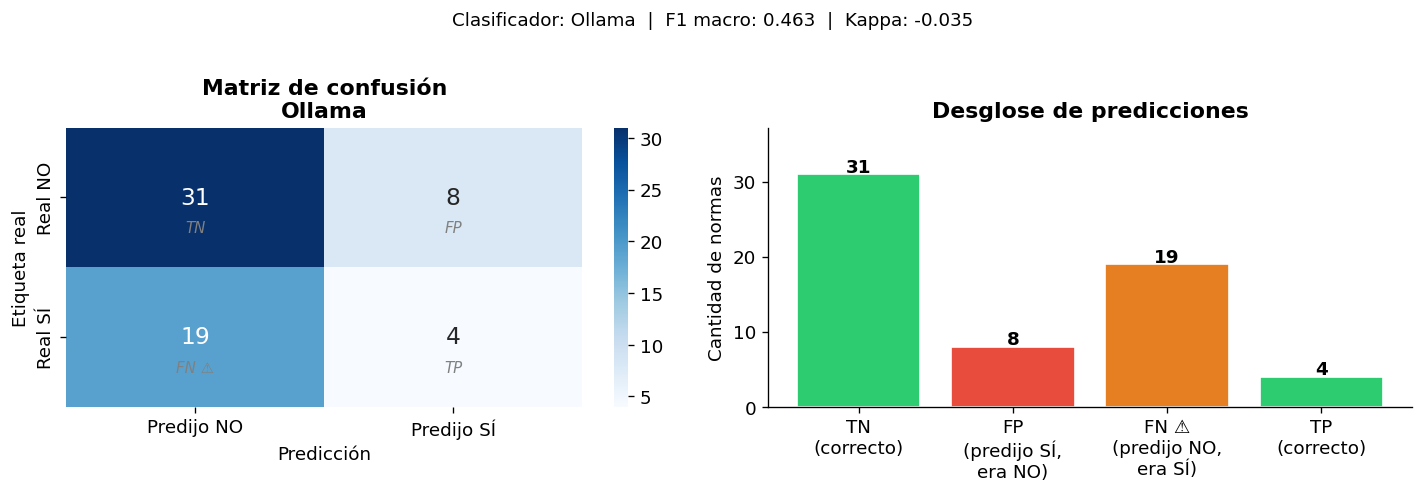

TN=31  FP=8  FN=19  TP=4
Total correctos: 35/62 (56.5%)
Total errores:   27/62 (43.5%)


In [6]:
cm = confusion_matrix(y_real, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=['Predijo NO', 'Predijo SÍ'],
    yticklabels=['Real NO', 'Real SÍ'],
    annot_kws={'size': 14}
)
ax.set_title(f'Matriz de confusión\n{NOMBRE_CLASIFICADOR}', fontweight='bold')
ax.set_ylabel('Etiqueta real')
ax.set_xlabel('Predicción')
for (i, j), label in [((0,0),'TN'), ((0,1),'FP'), ((1,0),'FN ⚠'), ((1,1),'TP')]:
    ax.text(j+0.5, i+0.75, label, ha='center', fontsize=9, color='gray', style='italic')


ax2 = axes[1]
categorias = ['TN\n(correcto)', 'FP\n(predijo SÍ,\nera NO)', 'FN ⚠\n(predijo NO,\nera SÍ)', 'TP\n(correcto)']
valores    = [tn, fp, fn, tp]
colores    = ['#2ecc71', '#e74c3c', '#e67e22', '#2ecc71']
bars = ax2.bar(categorias, valores, color=colores, edgecolor='white')
for bar, val in zip(bars, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontweight='bold')
ax2.set_title('Desglose de predicciones', fontweight='bold')
ax2.set_ylabel('Cantidad de normas')
ax2.set_ylim(0, max(valores) * 1.2)

n = len(merged)
plt.suptitle(f'Clasificador: {NOMBRE_CLASIFICADOR}  |  F1 macro: {metricas["F1 macro"]:.3f}  |  Kappa: {metricas["Kappa"]:.3f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Total correctos: {tn+tp}/{n} ({(tn+tp)/n:.1%})')
print(f'Total errores:   {fp+fn}/{n} ({(fp+fn)/n:.1%})')

## 6. Análisis de errores

Se muestran primero los **falsos negativos** (predijo NO, era SÍ) porque son más costosos.

In [7]:
errores = merged[merged['caso_ok_pred'] != merged['caso_ok_real']].copy()
errores['tipo_error'] = errores.apply(
    lambda r: 'FN — predijo NO, era SÍ' if r['caso_ok_pred'] == 0
              else 'FP — predijo SÍ, era NO',
    axis=1
)

print(f'Total errores: {len(errores)} de {n} ({len(errores)/n:.1%})')
print(errores['tipo_error'].value_counts().to_string())

Total errores: 27 de 62 (43.5%)
tipo_error
FN — predijo NO, era SÍ    19
FP — predijo SÍ, era NO     8


In [8]:
# ── Falsos negativos ──────────────────────────────────────────────────────────
fn_df = errores[errores['tipo_error'] == 'FN — predijo NO, era SÍ']

print(f'⚠️  Falsos negativos: {len(fn_df)} casos')
print('(El clasificador dijo NO pero la etiqueta real era SÍ)')
print()

cols = ['Número', 'Título'] if 'Título' in fn_df.columns else ['Número']
if 'Justificación' in fn_df.columns:
    cols.append('Justificación')

pd.set_option('display.max_colwidth', 80)
display(fn_df[cols].reset_index(drop=True))

⚠️  Falsos negativos: 19 casos
(El clasificador dijo NO pero la etiqueta real era SÍ)



,Número,Título,Justificación
0,5209,EMERGENCIA PéBLICA,0.0
1,26690,SUBSIDIOS,0.0
2,13116,ACCIDENTE DE AVIACION,0.0
3,1318,CORTE INTERAMERICANA DE DERECHOS HUMANOS,0.0
4,14414,SUBSIDIO ESTATAL,0.0
5,23280,GUERRA DE MALVINAS,0.0
6,525,ASISTENCIA FINANCIERA,0.0
7,812,DERECHOS HUMANOS,0.0
8,888,DUELO NACIONAL,0.0
9,636,MINISTERIO DE JUSTICIA Y DERECHOS HUMANOS,0.0


In [9]:
# ── Falsos positivos ──────────────────────────────────────────────────────────
fp_df = errores[errores['tipo_error'] == 'FP — predijo SÍ, era NO']

print(f'Falsos positivos: {len(fp_df)} casos')
print('(El clasificador dijo SÍ pero la etiqueta real era NO)')
print()

cols = ['Número', 'Título'] if 'Título' in fp_df.columns else ['Número']
if 'Justificación' in fp_df.columns:
    cols.append('Justificación')

display(fp_df[cols].reset_index(drop=True))

Falsos positivos: 8 casos
(El clasificador dijo SÍ pero la etiqueta real era NO)



,Número,Título,Justificación
0,26378,CONVENCIONES,1.0
1,26842,PREVENCION Y SANCION DE LA TRATA DE PERSONAS Y ASISTENCIA A SUS VICTIMAS,1.0
2,27508,FONDO FIDUCIARIO PUBLICO,1.0
3,25616,PROTOCOLOS,1.0
4,27402,ACUERDOS,1.0
5,23849,CONVENCIONES,1.0
6,27063,CODIGO PROCESAL PENAL FEDERAL,1.0
7,2372,CODIGO PROCESAL PENAL DE LA NACION,1.0


## 7. Comparación entre clasificadores (opcional)

Correr esta celda después de evaluar múltiples clasificadores para comparar sus métricas.

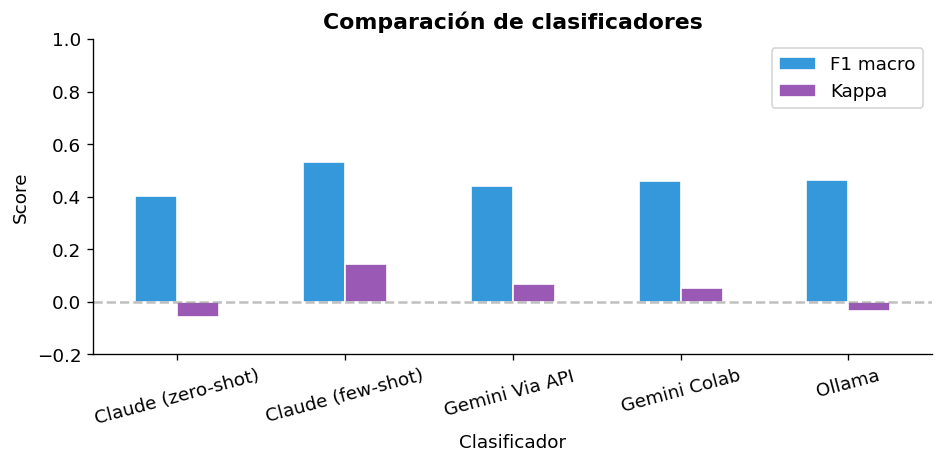

,F1 macro,Kappa
Clasificador,,
Claude (zero-shot),0.402,-0.057
Claude (few-shot),0.531,0.143
Gemini Via API,0.441,0.068
Gemini Colab,0.461,0.054
Ollama,0.463,-0.035


In [10]:
# Completar con los resultados de cada clasificador evaluado
# Copiar los valores de F1 macro y Kappa de cada ejecución anterior

resultados = [
    {'Clasificador': 'Claude (zero-shot)', 'F1 macro': 0.402, 'Kappa': -0.057},
    {'Clasificador': 'Claude (few-shot)', 'F1 macro':0.531 , 'Kappa': 0.143},
    {'Clasificador': 'Gemini Via API ',     'F1 macro': 0.441, 'Kappa': 0.068},
    {'Clasificador': 'Gemini Colab',    'F1 macro': 0.461, 'Kappa': 0.054},
    {'Clasificador': 'Ollama',          'F1 macro': 0.463, 'Kappa': -0.035},
]


if not resultados:
    print('Todavía no hay resultados para comparar. Completar la lista de arriba.')
else:
    df_comp = pd.DataFrame(resultados).set_index('Clasificador')

    ax = df_comp.plot(
        kind='bar', figsize=(8, 4),
        color=['#3498db', '#9b59b6'],
        edgecolor='white'
    )
    ax.set_title('Comparación de clasificadores', fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(-0.2, 1)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=15)
    ax.legend()
    plt.tight_layout()
    plt.show()

    display(df_comp)